Number of pedestrians detected: 11


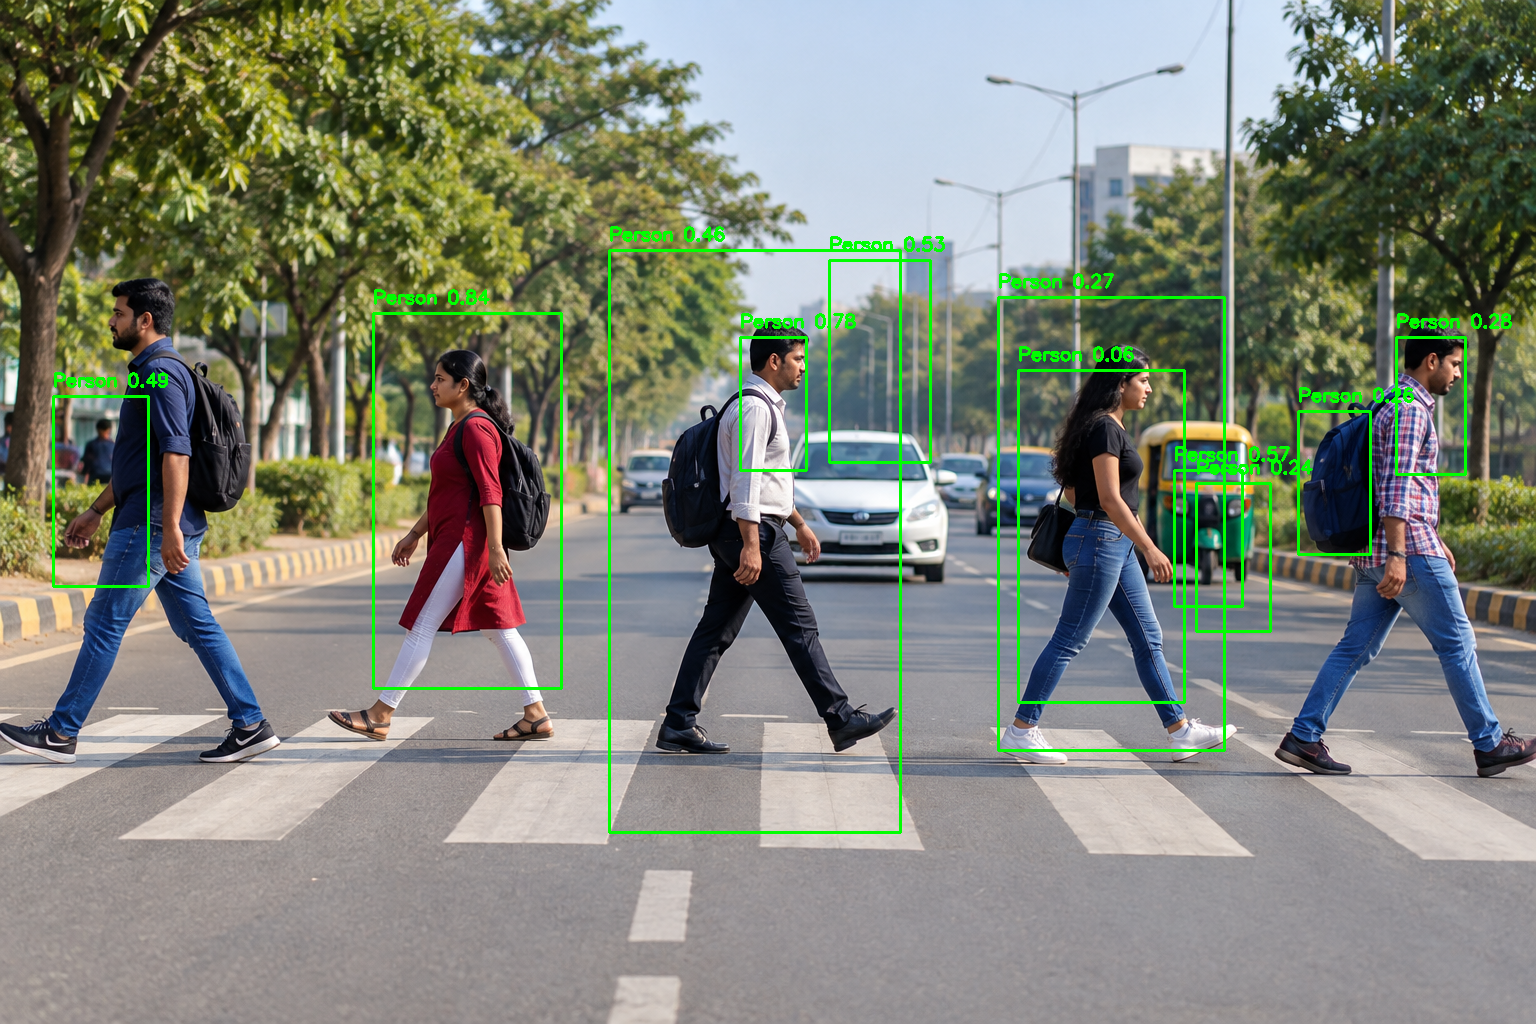

In [ ]:
#Write a program using OpenCV to detect pedestrians in an image using the HOG
#(Histogram of Oriented Gradients) descriptor.

import cv2
from google.colab.patches import cv2_imshow

# Read image
image = cv2.imread("road1.jpg")

if image is None:
    print("Image not found!")
    exit()

# Create HOG descriptor
hog = cv2.HOGDescriptor()

# Load OpenCV's pre-trained people detector
hog.setSVMDetector(
    cv2.HOGDescriptor_getDefaultPeopleDetector()
)

# Detect pedestrians
rects, weights = hog.detectMultiScale(
    image,
    winStride=(4, 4),
    padding=(8, 8),
    scale=1.03
)

# Draw bounding boxes
for (x, y, w, h), weight in zip(rects, weights):
    cv2.rectangle(
        image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        image,
        f"Person {float(weight):.2f}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

print("Number of pedestrians detected:", len(rects))

cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()